# To understand the text classification pipeline through the implementation of text vectorization.

# The Evolution of Text Classification & Representation

Before a computer can classify text, it must convert human language into math. We will explore this evolution step-by-step.

## 1. Bag of Words (BoW)
The most basic way to convert text to math is to simply count the words. BoW creates a "vocabulary" of every unique word in your dataset. For each sentence, it counts how many times each word appears.

It is called a "bag" because it completely ignores the order of the words—it just throws them all into a bag and counts them.

In [1]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer

# Dataset for the first few examples
corpus = [
    "I love machine learning.",
    "I love coding in Python.",
    "Machine learning is very fun.",
    "Python coding is fun."
]

print("--- 1. Bag of Words (BoW) ---")
bow_vectorizer = CountVectorizer()
X_bow = bow_vectorizer.fit_transform(corpus)

df_bow = pd.DataFrame(X_bow.toarray(), columns=bow_vectorizer.get_feature_names_out())
print(df_bow)

--- 1. Bag of Words (BoW) ---
   coding  fun  in  is  learning  love  machine  python  very
0       0    0   0   0         1     1        1       0     0
1       1    0   1   0         0     1        0       1     0
2       0    1   0   1         1     0        1       0     1
3       1    1   0   1         0     0        0       1     0


### Understanding the Bag of Words Output:
* **Alphabetical Order:** The columns (our newly created vocabulary words) are automatically sorted alphabetically from `coding` to `very`.
* **Lowercasing:** Notice that capital letters are gone. Words like "Machine" and "Python" were automatically converted to lowercase (`machine`, `python`) so that "Python" and "python" aren't accidentally counted as two separate words.
* **Where is the word "I"?:** By default, the `CountVectorizer` algorithm ignores single-letter words. It assumes that words like "I" or "a" don't carry enough meaningful weight for a machine learning model to classify a topic, so they are automatically dropped from the matrix!

### Bag of Words Evaluation
* **Pros:** Very simple to understand, fast to compute, and works decently well for basic topic classification.
* **Cons:** It completely destroys word order and context. To BoW, "The dog bit the man" and "The man bit the dog" have the exact same mathematical representation.

**The Fix:** How do we preserve *some* local word order without making things too complex? We use **N-Grams**.

## 2. N-Grams (Contextual Counting)
Instead of counting one word at a time (Unigrams), N-Grams count overlapping groups of words.
* **Bigrams (2-grams):** "machine learning", "is very", "very fun".
* **Trigrams (3-grams):** "machine learning is", "learning is very".

By grouping words, the algorithm starts to understand short phrases, realizing that the word "not" followed by "good" ("not good") means something entirely different than just "good".

In [2]:
print("--- 2. N-Grams (Bigrams) ---")

# ngram_range=(2, 2) tells it to ONLY look at pairs of words
ngram_vectorizer = CountVectorizer(ngram_range=(2, 2))
X_ngram = ngram_vectorizer.fit_transform(corpus)

df_ngram = pd.DataFrame(X_ngram.toarray(), columns=ngram_vectorizer.get_feature_names_out())
print(df_ngram)

--- 2. N-Grams (Bigrams) ---
   coding in  coding is  in python  is fun  is very  learning is  love coding  \
0          0          0          0       0        0            0            0   
1          1          0          1       0        0            0            1   
2          0          0          0       0        1            1            0   
3          0          1          0       1        0            0            0   

   love machine  machine learning  python coding  very fun  
0             1                 1              0         0  
1             0                 0              0         0  
2             0                 1              0         1  
3             0                 0              1         0  


### Understanding the N-Gram (Bigram) Output:
* **Pairs of Words:** Notice that every column header is now exactly two words long (e.g., `machine learning`, `is very`). This is because we set `ngram_range=(2, 2)`.
* **Capturing Context:** Look at ("I love machine learning"). It successfully captured the phrase `machine learning`. In simple Bag of Words, "machine" and "learning" were completely separate, meaning the algorithm didn't know they belonged together!
* **Where did "I love" go?:** Just like in Bag of Words, the algorithm automatically drops single-letter words like "I" by default. So instead of finding the bigram "I love", it skips the "I" and just starts looking at the next valid words. This is why "love machine" and "love coding" are the first pairs it picks up for those sentences.
* **Increased Columns:** Notice how wide this matrix is getting! We only have 4 tiny sentences, but we generated 11 unique bigrams. This shows one of the main downsides of N-Grams: your vocabulary size can explode very quickly on large datasets.

### N-Grams Evaluation
* **Pros:** Captures local context and basic grammar structure.
* **Cons:** The vocabulary size explodes. If you have 10,000 unique words, you could have hundreds of thousands of bigrams. Also, both BoW and N-Grams treat all words equally. The word "is" gets counted just as heavily as the word "machine".

**The Fix:** How do we tell the computer to mathematically ignore useless words and highlight important ones? We use **TF-IDF**.

## 3. TF-IDF (Term Frequency - Inverse Document Frequency)
TF-IDF doesn't just count words; it **weighs** them based on their informational value.


* **Term Frequency (TF):** How often does the word appear in this specific sentence?
* **Inverse Document Frequency (IDF):** How rare is this word across *all* sentences?

If a word is frequent in one sentence but rare globally (like "Python"), it gets a high score. If a word is frequent everywhere (like "is"), its score is penalized and drops close to zero.

In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer

print("--- 3. TF-IDF ---")
tfidf_vectorizer = TfidfVectorizer()
X_tfidf = tfidf_vectorizer.fit_transform(corpus)

df_tfidf = pd.DataFrame(X_tfidf.toarray(), columns=tfidf_vectorizer.get_feature_names_out())

# Notice the decimal weights. The algorithm has learned that "machine" is mathematically more important than "is"!
print(df_tfidf.round(2))

--- 3. TF-IDF ---
   coding   fun    in    is  learning  love  machine  python  very
0    0.00  0.00  0.00  0.00      0.58  0.58     0.58    0.00  0.00
1    0.47  0.00  0.59  0.00      0.00  0.47     0.00    0.47  0.00
2    0.00  0.42  0.00  0.42      0.42  0.00     0.42    0.00  0.54
3    0.50  0.50  0.00  0.50      0.00  0.00     0.00    0.50  0.00


### Understanding the TF-IDF Output:
* **No More Whole Numbers:** Unlike Bag of Words which just outputs `1` or `2`, TF-IDF outputs **decimal weights** (between 0.0 and 1.0).
* **Understand the Weighting:** Look at ("Machine learning is very fun.").
    * The word `very` gets the highest score (**0.54**) because it appears in this sentence, but is extremely rare in the rest of the dataset (it only appears here!).
    * The word `is` gets a much lower score (**0.42**). Even though it appears in this sentence, the algorithm notices that `is` also appears in another statements Because it's a more common word across the whole dataset, it gets penalized and receives less weight!
* **Why does this matter?:** By automatically penalizing common words and highlighting rare words, TF-IDF acts as a built-in filter, feeding the classification algorithm only the most meaningful, descriptive words.

### TF-IDF Evaluation
* **Pros:** Excellent at finding the most descriptive words in a dataset. The industry standard baseline for text classification.
* **Cons:** It still doesn't understand **meaning**. To TF-IDF, the word "happy" and the word "joyful" are completely unrelated distinct columns. The matrix is also incredibly sparse (mostly zeros).

**The Fix:** How do we teach the computer that "happy" and "joyful" are synonyms? We compress the vocabulary into dense mathematical coordinates using **Word Embeddings**.

## 4. Word Embeddings (Word2Vec)
Word embeddings abandon the idea of counting entirely. Instead, they plot words as coordinates in a multi-dimensional space.

If two words frequently appear in the same context, the neural network pulls their coordinates closer together. The AI actually learns semantic relationships!

In [5]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 57.4 MB/s eta 0:00:00


### 💡 what is `gensim`?
While we used `scikit-learn` for counting words (BoW and TF-IDF), **Gensim** is a different Python library specifically built for understanding word *meaning*.

* **The Home of Word2Vec:** Gensim contains the industry-standard, highly optimized version of Google's Word2Vec algorithm.
* **Built for Big Data:** It is designed to process massive text datasets (like all of Wikipedia) without crashing your computer's memory. We import it here simply to borrow its powerful Word2Vec brain!

In [8]:
from gensim.models import Word2Vec

# Word2Vec requires tokenized lists of words
tokenized_corpus = [
    ['i', 'love', 'machine', 'learning'],
    ['i', 'love', 'coding', 'in', 'python'],
    ['machine', 'learning', 'is', 'very', 'fun'],
    ['python', 'coding', 'is', 'fun']
]

print("--- 4. Word2Vec Embeddings ---")
# vector_size=5 means we compress the meaning of the word into 5 coordinates
model = Word2Vec(sentences=tokenized_corpus, vector_size=5, window=2, min_count=1)

print("\nThe Mathematical Meaning of 'python':")
print(model.wv['python'])

print("\nWords most similar to 'coding' in our tiny dataset:")
print(model.wv.most_similar('coding', topn=2))

# Compare two specific words (Cosine Similarity)
print("\nSimilarity score between 'machine' and 'learning':")
print(model.wv.similarity('machine', 'learning'))

# Find the "Odd One Out"
print("\nWhich word doesn't belong: ['machine', 'learning', 'fun']?")
print(model.wv.doesnt_match(['machine', 'learning', 'fun']))

# See the entire vocabulary the model learned
print("\nAll the words the model knows:")
print(model.wv.index_to_key)

--- 4. Word2Vec Embeddings ---

The Mathematical Meaning of 'python':
[ 0.1476101  -0.03066943 -0.09073226  0.13108103 -0.09720321]

Words most similar to 'coding' in our tiny dataset:
[('machine', 0.7668752074241638), ('is', 0.6178626418113708)]

Similarity score between 'machine' and 'learning':
-0.15349132

Which word doesn't belong: ['machine', 'learning', 'fun']?
learning

All the words the model knows:
['fun', 'is', 'python', 'coding', 'learning', 'machine', 'love', 'i', 'very', 'in']


In [9]:
from gensim.models import Word2Vec

# Let's use a structured dataset with two distinct contexts: Tech and Food
tokenized_corpus = [
    # Tech / Coding context
    ['python', 'is', 'a', 'programming', 'language'],
    ['java', 'is', 'a', 'programming', 'language'],
    ['coding', 'in', 'python', 'is', 'great'],
    ['coding', 'in', 'java', 'is', 'great'],
    ['developers', 'write', 'code', 'in', 'python'],
    ['developers', 'write', 'code', 'in', 'java'],
    # Food / Eating context
    ['pizza', 'is', 'a', 'delicious', 'food'],
    ['burger', 'is', 'a', 'delicious', 'food'],
    ['i', 'love', 'eating', 'pizza'],
    ['i', 'love', 'eating', 'burger'],
    ['chefs', 'cook', 'delicious', 'food']
]

print("--- 4. Word2Vec Embeddings ---")

# epochs=100 , forces the AI to read these 11 sentences
# 100 times so it can actually learn the relationships.
model = Word2Vec(sentences=tokenized_corpus, vector_size=10, window=2, min_count=1, epochs=100, seed=42)

print("\nThe Mathematical Meaning of 'python' (First 5 coordinates):")
print(model.wv['python'][:5], "...")

print("\nWords most similar to 'python':")
print(model.wv.most_similar('python', topn=2))

# Compare two food words
print("\nSimilarity score between 'pizza' and 'burger':")
print(f"{model.wv.similarity('pizza', 'burger'):.4f}")

# Find the "Odd One Out"
print("\nWhich word doesn't belong: ['python', 'java', 'pizza']?")
print(model.wv.doesnt_match(['python', 'java', 'pizza']))

--- 4. Word2Vec Embeddings ---

The Mathematical Meaning of 'python' (First 5 coordinates):
[ 0.0876516   0.04959372 -0.02655467  0.09474537 -0.0139755 ] ...

Words most similar to 'python':
[('write', 0.438281387090683), ('chefs', 0.3961808681488037)]

Similarity score between 'pizza' and 'burger':
-0.4532

Which word doesn't belong: ['python', 'java', 'pizza']?
pizza


### Word2Vec Evaluation
* **Pros:** Understands synonyms, captures deep semantic meaning, and creates dense, memory-efficient vectors.
* **Cons:** It is **static**. Word2Vec assigns exactly one vector to a word. For example, the word "Bank" gets the same math whether the sentence is "River bank" or "Deposit money in the bank."

**The Fix:** How do we give words different mathematical values based on the sentence they are in? We enter the modern AI era with **Contextual Embeddings (BERT)**.

## 5. Contextual Embeddings (Transformers / BERT)
Transformers (the architecture behind ChatGPT and modern AI) read the *entire* sentence at once before converting anything to math.

They use an "Attention Mechanism" to look at the surrounding words. Because of this, the word "bank" will have completely different mathematical coordinates depending on the context of the sentence.

In [10]:
!pip install -q sentence-transformers

In [12]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

print("--- 5. BERT Contextual Embeddings ---")
bert_model = SentenceTransformer('all-MiniLM-L6-v2')

# Let's test the "Bank" problem
sentences = [
    "I need to deposit money in the bank.",   # Financial
    "I sat by the river bank.",               # Nature
    "I withdrew cash from the ATM."           # Financial (Different words!)
]

embeddings = bert_model.encode(sentences)

print("\nCosine Similarity (Closer to 1.0 means same meaning):")
sim_1 = cosine_similarity([embeddings[0]], [embeddings[1]])[0][0]
sim_2 = cosine_similarity([embeddings[0]], [embeddings[2]])[0][0]

print(f"Deposit money vs River bank:  {sim_1:.4f} (Low - BERT knows they are different!)")
print(f"Deposit money vs ATM cash:    {sim_2:.4f} (High - BERT knows they share context!)")

--- 5. BERT Contextual Embeddings ---


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Cosine Similarity (Closer to 1.0 means same meaning):
Deposit money vs River bank:  0.3702 (Low - BERT knows they are different!)
Deposit money vs ATM cash:    0.4220 (High - BERT knows they share context!)


### BERT Evaluation
* **Pros:** State-of-the-art accuracy. Perfectly handles context, sarcasm, double meanings, and synonyms.
* **Cons:** Extremely computationally expensive. Requires GPUs to run efficiently and takes massive amounts of data to train from scratch.

### Summary
For simple, fast text classification tasks where keywords matter most, **TF-IDF** paired with Naive Bayes is still an incredibly powerful tool. But when deep human understanding, context, and semantic meaning are required, **Transformers (BERT)** are the gold standard.


#  **Perform this practical byself**

# Text Classification: Spam Detection

We give the algorithm examples of text and their correct labels (e.g., "Spam" or "Not Spam"), and it learns how to categorize new, unseen text.

### The Problem: Computers Can't Read Text
Machine learning algorithms only understand numbers. Before we can train a classifier, we must convert our raw text data (sentences) into a numerical format. This process is called **Feature Extraction** or **Vectorization**.

### Step 1: TF-IDF Vectorization
The most common way to convert text to numbers is **TF-IDF (Term Frequency - Inverse Document Frequency)**.
* **Term Frequency (TF):** How many times does a word appear in a specific message? (If "FREE" appears 3 times in a text, it's important to that text).
* **Inverse Document Frequency (IDF):** How rare is the word across *all* messages? (Words like "the" or "and" appear everywhere, so they are penalized. Rare words get a higher weight).



Multiplying these together gives every word a specific weight. A high TF-IDF score means the word is highly relevant to that specific message but relatively rare in the entire dataset.

### Step 2: The Naive Bayes Algorithm
Once the text is converted into a matrix of TF-IDF numbers, we feed it into a classification algorithm. **Multinomial Naive Bayes** is the go-to algorithm for text.

It is based on Bayes' Theorem of probability:
$$P(A|B) = \frac{P(B|A) \cdot P(A)}{P(B)}$$

It calculates the probability that a message is Spam *given* the specific words it contains. It looks at historical data and says, "Since this message contains the words 'Win', 'Cash', and 'Urgent', there is a 98% probability it is Spam."

#  **Perform this Practical byself**

In [21]:

# 1. IMPORTING LIBRARIES & LOADING DATA

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load a public SMS Spam dataset
url = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"
# This file is tab-separated, so we use sep='\t'
df = pd.read_csv(url, sep='\t', header=None, names=['label', 'message'])

print("--- First 5 rows of the dataset ---")
print(df.head())

# Check the balance of our classes (How many Spam vs Ham/Not-Spam?)
print("\n--- Class Distribution ---")
print(df['label'].value_counts())


--- First 5 rows of the dataset ---
  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...

--- Class Distribution ---
label
ham     4825
spam     747
Name: count, dtype: int64


In [14]:

# 2. DATA PREPROCESSING

# Convert labels to binary numbers (ham = 0, spam = 1)
df['label_num'] = df['label'].map({'ham': 0, 'spam': 1})

# Define our Features (X) and Target (y)
X = df['message']  # The raw text
y = df['label_num'] # The target label (0 or 1)

# Split the data into Training Data (80%) and Testing Data (20%)
# random_state ensures we get the same split every time we run the code
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nTraining messages: {X_train.shape[0]}")
print(f"Testing messages: {X_test.shape[0]}")



Training messages: 4457
Testing messages: 1115


In [15]:

# 3. FEATURE EXTRACTION (TEXT TO NUMBERS)

# Initialize the TF-IDF Vectorizer
# stop_words='english' automatically removes common useless words like 'the', 'is', 'and'
vectorizer = TfidfVectorizer(stop_words='english')

# Fit the vectorizer on the training data and transform it into a numerical matrix
X_train_dtm = vectorizer.fit_transform(X_train)

# ONLY transform the testing data (do not fit! We want to test on unseen vocabulary)
X_test_dtm = vectorizer.transform(X_test)


In [17]:
# 4. TRAINING THE CLASSIFICATION MODEL

# Initialize the Multinomial Naive Bayes classifier
nb_model = MultinomialNB()

# Train the model using the numerical training data and training labels
nb_model.fit(X_train_dtm, y_train)


MultinomialNB()

In [18]:
# 5. MAKING PREDICTIONS & EVALUATION

# Ask the model to predict the labels for our test set
y_pred = nb_model.predict(X_test_dtm)

# Calculate Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"\n--- Model Accuracy: {accuracy * 100:.2f}% ---")

# Print a detailed classification report (Precision, Recall, F1-Score)
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=['Ham (Not Spam)', 'Spam']))



--- Model Accuracy: 97.85% ---

--- Classification Report ---
                precision    recall  f1-score   support

Ham (Not Spam)       0.98      1.00      0.99       966
          Spam       1.00      0.84      0.91       149

      accuracy                           0.98      1115
     macro avg       0.99      0.92      0.95      1115
  weighted avg       0.98      0.98      0.98      1115



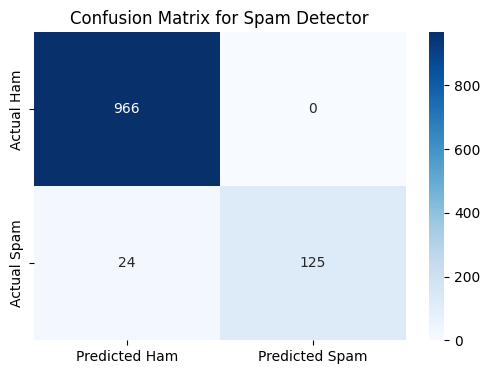

In [19]:
# 6. VISUALIZING THE CONFUSION MATRIX

# A confusion matrix shows exactly where the model got confused
# (e.g., predicting Spam when it was actually Ham)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Ham', 'Predicted Spam'],
            yticklabels=['Actual Ham', 'Actual Spam'])
plt.title('Confusion Matrix for Spam Detector')
plt.show()

In [20]:
# 7. TEST IT YOURSELF!

# Let's write a quick function to test our own custom messages
def predict_spam(text):
    text_dtm = vectorizer.transform([text])
    prediction = nb_model.predict(text_dtm)
    return "SPAM " if prediction[0] == 1 else "NOT SPAM "

print("\n--- Testing Custom Messages ---")
print(f"Message 1: 'Hey, are we still on for lunch tomorrow?' -> {predict_spam('Hey, are we still on for lunch tomorrow?')}")
print(f"Message 2: 'CONGRATULATIONS! You won a $1000 Walmart gift card. Click here to claim your prize now!' -> {predict_spam('CONGRATULATIONS! You won a $1000 Walmart gift card. Click here to claim your prize now!')}")


--- Testing Custom Messages ---
Message 1: 'Hey, are we still on for lunch tomorrow?' -> NOT SPAM 
Message 2: 'CONGRATULATIONS! You won a $1000 Walmart gift card. Click here to claim your prize now!' -> SPAM 
